<span style="float: left;padding: 1.3em">![logo](Ligo.png)</span>
<span style="float: right;padding: 1.3em">![logo](Zewail-City.png)</span>

---
# Challenge #2 (_Rookie_)

In [1]:
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

In [2]:
# Main Libraries
from pycbc.frame import read_frame
from pycbc.types import TimeSeries
from pycbc.filter import highpass, matched_filter
from pycbc.psd import interpolate, inverse_spectrum_truncation, welch
from pycbc.waveform import get_td_waveform
import matplotlib.pyplot as plt
import numpy as np

### Use the data file challenge2.gwf, with channel name H1:CHALLENGE2.
### The data contain a BBH signal with m1 = m2 = 30 solar masses, spin = 0.

In [3]:
# Data
file_name = "challenge2.gwf"
channel = "H1:CHALLENGE2"

ts = read_frame(file_name, channel)

In [4]:
# Sampling rate
sampling_rate = ts.sample_rate
print("Sampling rate:", sampling_rate)

# Duration
duration = ts.duration
print("Duration (s):", duration)

Sampling rate: 4096.0
Duration (s): 128.0


### What is the approximative time of the merger? (Hint: a plot of the q-transform could help)

In [5]:
# Filtering
ts_filtered = highpass(ts, 15.0)
ts_whitened = ts_filtered.whiten(4, 4)

times, freqs, qplane = ts_whitened.qtransform(
    delta_t=0.001,
    logfsteps=100,
    qrange=(4, 64),
    frange=(20, 512)
)

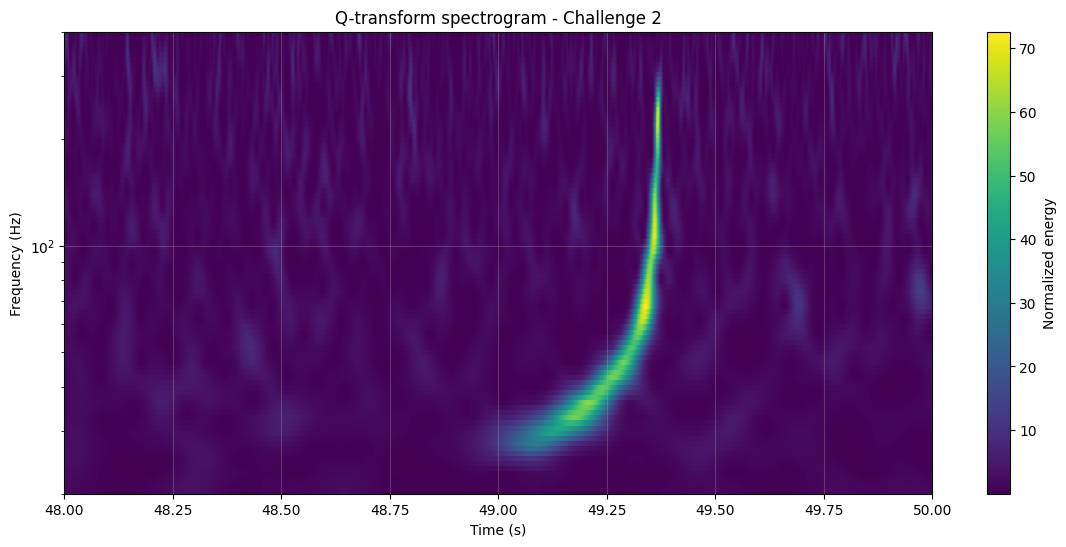

In [6]:
# Plot
plt.figure(figsize=(14, 6))
plt.pcolormesh(times, freqs, qplane, cmap='viridis', shading='auto')
plt.colorbar(label='Normalized energy')
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title("Q-transform spectrogram - Challenge 2")
plt.yscale('log')
plt.ylim(20, 400)
plt.xlim(48, 50)
plt.grid(alpha=0.3)
plt.show()

In [7]:
# Find approximate merger time from peak in data
peak_index = np.argmax(abs(ts))
merger_time = ts.sample_times[peak_index]
print("Approximate merger time:", merger_time, "s")

Approximate merger time: 19.856201171875 s


### Generate a time-domain template waveform using approximate `SEOBNRv4_opt`. with the same parameters as above. Plot this waveform.

In [8]:
# Parameters: m1 = m2 = 30 solar masses, spin = 0

hp, hc = get_td_waveform(
    approximant='SEOBNRv4_opt',
    mass1=30,
    mass2=30,
    spin1z=0,
    spin2z=0,
    delta_t=1.0/ts.sample_rate,
    f_lower=20.0
)

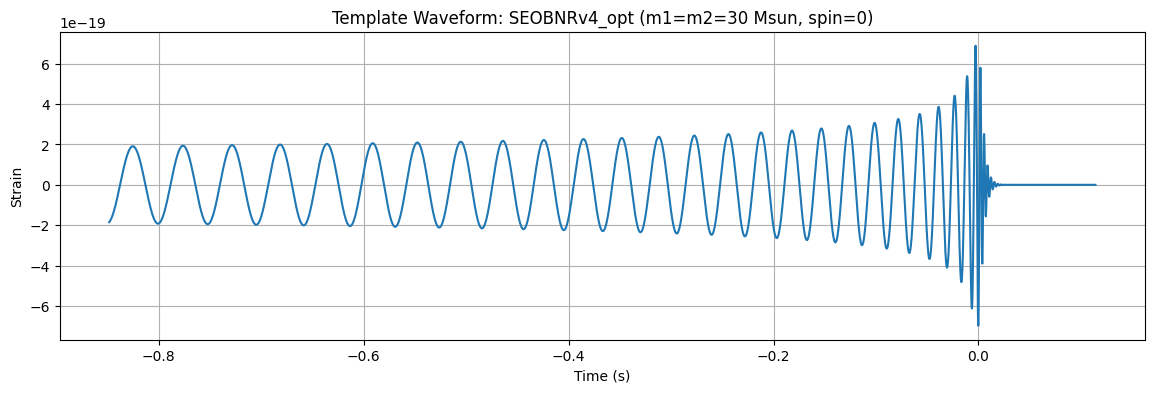

In [9]:
# Plot
plt.figure(figsize=(14, 4))
plt.plot(hp.sample_times, hp)
plt.xlabel("Time (s)")
plt.ylabel("Strain")
plt.title("Template Waveform: SEOBNRv4_opt (m1=m2=30 Msun, spin=0)")
plt.grid()
plt.show()

### Calculate a PSD of the data, and plot this on a log-log scale. Use axes ranging from 20 Hz up to the Nyquist frequency.

In [10]:
# Calculate PSD using Welch method
psd = welch(ts, seg_len=int(4*ts.sample_rate), seg_stride=int(2*ts.sample_rate))

# Nyquist frequency
nyquist_freq = ts.sample_rate / 2

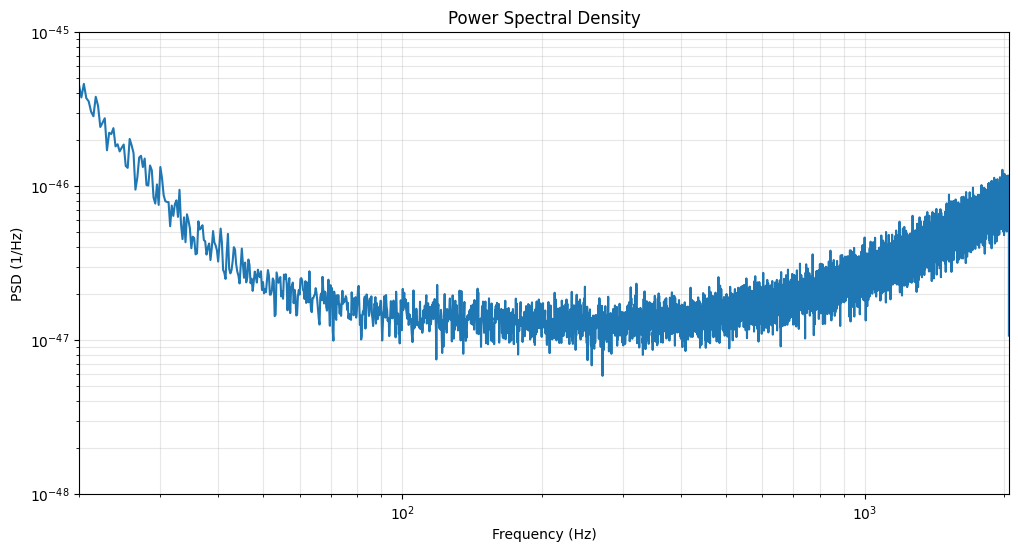

In [11]:
# Plot
plt.figure(figsize=(12, 6))
plt.loglog(psd.sample_frequencies, psd)
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD (1/Hz)")
plt.title("Power Spectral Density")
plt.xlim(20, nyquist_freq)
plt.ylim(1e-48, 1e-45)
plt.grid(which='both', alpha=0.3)
plt.show()

### Use the template waveform and PSD to calculate the SNR time series. Plot the SNR time-series.

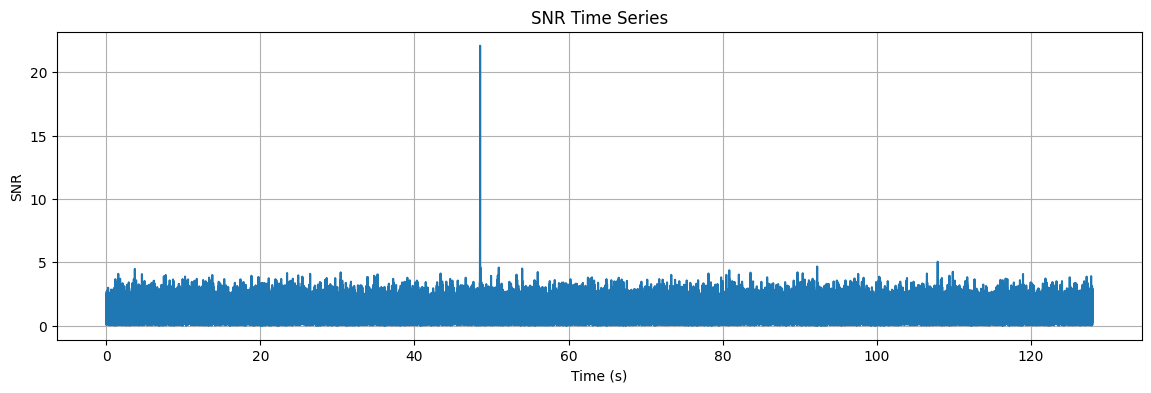

In [12]:
# Resize template to match data length
hp.resize(len(ts))

# Interpolate PSD to match the data's frequency resolution
psd_interp = interpolate(psd, hp.delta_f)

# Calculate matched filter SNR
snr = matched_filter(hp, ts, psd=psd_interp, low_frequency_cutoff=20.0)

# Plot SNR time series
plt.figure(figsize=(14, 4))
plt.plot(snr.sample_times, abs(snr))
plt.xlabel("Time (s)")
plt.ylabel("SNR")
plt.title("SNR Time Series")
plt.grid()
plt.show()

### What is the matched filter SNR of the signal?

In [13]:
peak_snr_index = np.argmax(abs(snr))
peak_snr = abs(snr[peak_snr_index])
peak_time = snr.sample_times[peak_snr_index]

print("Matched filter SNR:", peak_snr)
print("Peak SNR time:", peak_time, "s")

Matched filter SNR: 22.097761457174073
Peak SNR time: 48.5185546875 s


---